# <font color='#3c3c3c'>EDA</font>

In [37]:
import pandas as pd
images_csv = 'sintetic_dataset/rotated_dataset.csv'
images_folder = 'sintetic_dataset/rotated_synthetic'
df = pd.read_csv(images_csv)

In [38]:
display(df.head())

,unique_identifier,inner,outer,degree_rotation_inner,degree_rotation_outer,degree_rotation_total,dataset,correct_angle
0,0,000_inner.jpg,000_outer.jpg,-171.32,-171.72,-0.40,rotated_synthetic,-0.40
1,1,001_inner.jpg,001_outer.jpg,3.24,-95.96,-99.20,rotated_synthetic,-99.20
2,2,002_inner.jpg,002_outer.jpg,-100.00,89.48,189.48,rotated_synthetic,189.48
3,3,003_inner.jpg,003_outer.jpg,-154.46,15.21,169.67,rotated_synthetic,169.67
4,4,004_inner.jpg,004_outer.jpg,-165.77,20.90,186.68,rotated_synthetic,186.68


In [39]:
max_value = df['correct_angle'].max()
min_value = df['correct_angle'].min()

print(max_value)
print(min_value)


338.07
-303.88


In [40]:
!pip install plotly


[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


In [41]:
import plotly.express as px

fig = px.histogram(
    df,
    x='correct_angle',
    nbins=50,
    title='Correct Alignment Distribution',
    opacity=0.7
)

fig.update_layout(
    xaxis_title='Correct Angle',
    yaxis_title='Frequence'
)

fig.show()


Angle Range & Wrap Check (makes sure that is the angle is between 0 and 360 and contains no missing values)


In [42]:
df['correct_angle'] = (df['degree_rotation_inner'] - df['degree_rotation_outer']) % 360


In [43]:
print("Min angle:", df['correct_angle'].min())
print("Max angle:", df['correct_angle'].max())
print("NaNs in correct_angle:", df['correct_angle'].isna().sum())



Min angle: 0.4000000000000057
Max angle: 359.71
NaNs in correct_angle: 0


Convert to Angle Class (This needs to be analyzed)(this is using the 72 classes)

In [44]:
df['angle_class'] = (df['correct_angle'] // 5).astype(int)


Angle Class Distribution

Text(0, 0.5, 'Count')

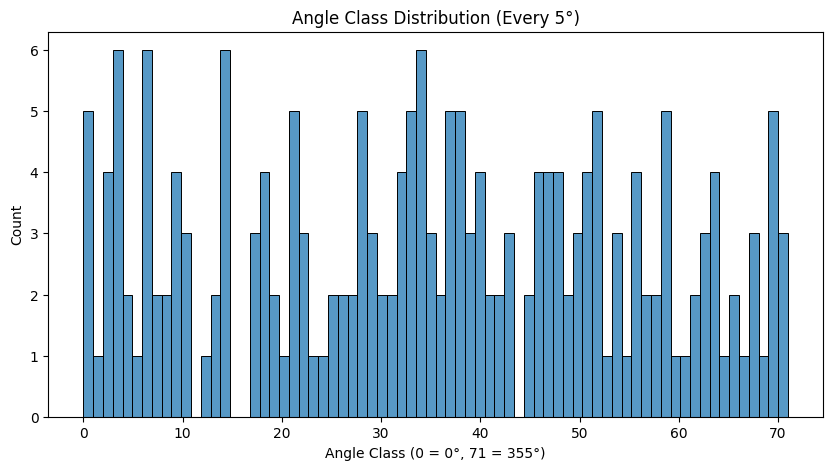

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.histplot(df['angle_class'], bins=72)
plt.title("Angle Class Distribution (Every 5°)")
plt.xlabel("Angle Class (0 = 0°, 71 = 355°)")
plt.ylabel("Count")



In [46]:
missing = set(range(72)) - set(df['angle_class'].unique())
print("Missing angle classes:", sorted(missing))

# DONT RUN YET WE WILL FIX THIS IN DATA IMPUTATION

Missing angle classes: [11, 15, 16, 44]


Inner vs Outer Rotation Check


In [47]:
df_copy = df.copy()

df_copy['computed_correct_angle'] = (df_copy['degree_rotation_inner'] - df_copy['degree_rotation_outer']) % 360

mismatch = (df_copy['correct_angle'] != df_copy['computed_correct_angle']).sum()
print("Mismatched labels:", mismatch)


Mismatched labels: 0


Check Base Image Coverage


In [57]:
print("Unique identifiers:", df['unique_identifier'].nunique())


Unique identifiers: 200


Group Stats by Base Image


In [56]:
df['unique_identifier'].value_counts().describe()


count    200.0
mean       1.0
std        0.0
min        1.0
25%        1.0
50%        1.0
75%        1.0
max        1.0
Name: count, dtype: float64

Label Entropy
How balanced is your angle class distribution?


In [50]:
from scipy.stats import entropy
counts = df['angle_class'].value_counts()
print("Angle class entropy:", entropy(counts))


Angle class entropy: 4.08674976422997


DATA SPLITTING 

In [58]:
from sklearn.model_selection import GroupShuffleSplit

# First: split 70% Train, 30% Temp (for Val + Test)
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx, temp_idx = next(gss1.split(df, groups=df['base_image_id']))

train_df = df.iloc[train_idx]
temp_df = df.iloc[temp_idx]

# Then: split Temp into 15% and 15%
gss2 = GroupShuffleSplit(n_splits=1, test_size=1/2, random_state=42)
val_idx, test_idx = next(gss2.split(temp_df, groups=temp_df['base_image_id']))

val_df = temp_df.iloc[val_idx]
test_df = temp_df.iloc[test_idx]


In [59]:
print("Train base images:", train_df['base_image_id'].nunique())
print("Validation base images:", val_df['base_image_id'].nunique())
print("Test base images:", test_df['base_image_id'].nunique())


Train base images: 140
Validation base images: 30
Test base images: 30


DATA IMPUTATION AND AUGMENTATION

Generating examples for missing classes seen earlier

In [61]:
df['angle_class'] = (df['correct_angle'] // 5).astype(int)
missing_classes = sorted(set(range(72)) - set(df['angle_class'].unique()))
print("Missing classes:", missing_classes)






Missing classes: [11, 15, 16, 44]


WE ARE NOT GONNA DO THIS YET 

DATA AUGMENTATION

In [63]:
train_df.to_csv("train_df.csv", index=False)
val_df.to_csv("val_df.csv", index=False)
test_df.to_csv("test_df.csv", index=False)


In [64]:
import cv2
import numpy as np

def apply_cartoon_effect(img):
    # Example cartoon effect
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = cv2.medianBlur(gray, 5)
    edges = cv2.adaptiveThreshold(gray, 255,
                                  cv2.ADAPTIVE_THRESH_MEAN_C,
                                  cv2.THRESH_BINARY, 9, 9)
    color = cv2.bilateralFilter(img, 9, 250, 250)
    cartoon = cv2.bitwise_and(color, color, mask=edges)
    return cartoon

def apply_grayscale(img):
    return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

def apply_blur(img, kernel_size=5):
    return cv2.GaussianBlur(img, (kernel_size, kernel_size), 0)

def apply_inversion(img):
    return cv2.bitwise_not(img)

def apply_solarization(img):
    return cv2.threshold(img, 128, 255, cv2.THRESH_BINARY)[1]

def apply_pixelation(img, pixel_size=5):
    h, w = img.shape[:2]
    temp = cv2.resize(img, (w // pixel_size, h // pixel_size), interpolation=cv2.INTER_LINEAR)
    return cv2.resize(temp, (w, h), interpolation=cv2.INTER_NEAREST)

# You can define pastel and vintage similar to the above.


In [65]:
import pandas as pd

df = pd.read_csv("train_df.csv")


In [66]:
from random import choice

transformations = [
    ("cartoon", apply_cartoon_effect),
    ("grayscale", apply_grayscale),
    ("blur5", lambda img: apply_blur(img, 5)),
    ("blur9", lambda img: apply_blur(img, 9)),
    ("inversion", apply_inversion),
    ("solarization", apply_solarization),
    ("pixel5", lambda img: apply_pixelation(img, 5)),
    ("pixel10", lambda img: apply_pixelation(img, 10))
]
